In [ ]:
import pandas as pd
import pyarrow.parquet as pq
# Path to your downloaded .txt file
input_file = '46_Col_final_with_county.parquet'
# Path where you want to save the new .csv

chunk_size = 100000
null_counts = None
total_rows = 0
parquet_file = pq.ParquetFile(input_file)

# Iterate through "Row Groups" (the Parquet version of chunks)
for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(i).to_pandas()
    if null_counts is None:
        null_counts = chunk.isnull().sum()
    else:
        null_counts += chunk.isnull().sum()
    total_rows += len(chunk)

# Get the list
null_percentages = null_counts / total_rows


print(f"Total Rows: {total_rows}")
print("Columns to remove (>50% null):", high_null_cols)

Total Rows: 1351582
Columns to remove (>50% null): []


In [5]:
sorted_null_counts = null_counts.sort_values(ascending=False)
print(sorted_null_counts[sorted_null_counts>0])

PredominantRoofType          141260
PercentageDraughtStripped     24127
NoOfSidesSheltered            24127
SuspendedWoodenFloor          24127
StructureType                 24127
VentilationMethod             24127
NoOfFansAndVents              24127
WHRenewableResources          23467
SupplWHFuel                   23467
SupplSHFuel                   23467
WHEffAdjFactor                23467
WHMainSystemEff               23467
HSSupplSystemEff              23467
HSSupplHeatFraction           23467
HSEffAdjFactor                23467
SHRenewableResources          23467
HSMainSystemEfficiency        23467
dtype: int64


In [10]:
import pandas as pd

# Path to your file
input_file = '46_Col_final_with_county.parquet'

# 1. Identify the groups of columns with the same NULL count
# (Assuming you already have 'null_counts' from your previous step)
counts_series = null_counts[null_counts > 0]
duplicates = counts_series[counts_series.duplicated(keep=False)]
groups = duplicates.groupby(duplicates.values).groups

# 2. Initialize counters to track overlaps
# This will count how many rows are null for ALL columns in a group
overlap_trackers = {count: 0 for count in groups.keys()}

print(f"Processing in chunks to check overlap for {len(groups)} groups...")

# 3. Iterate through the file in chunks
chunk_size = 100000
for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(i).to_pandas()
    for count_val, cols in groups.items():
        # For this chunk, count rows where EVERY column in the group is null
        is_fully_null = chunk[list(cols)].isnull().all(axis=1)
        overlap_trackers[count_val] += is_fully_null.sum()

# 4. Print the final analysis
print("\n" + "="*50)
print("NULL ROW OVERLAP ANALYSIS")
print("="*50)

for count_val, cols in groups.items():
    actual_overlap = overlap_trackers[count_val]
    
    print(f"\nGroup Shared Count: {count_val}")
    print(f"Columns: {list(cols)}")
    
    if actual_overlap == count_val:
        print(f"✅ SUCCESS: These columns are missing data in the EXACT SAME {count_val} rows.")
        print("   (Conclusion: These columns belong to a specific survey block that was skipped.)")
    else:
        print(f"❌ PARTIAL OVERLAP: Only {actual_overlap} rows overlap out of {count_val}.")
        print("   (Conclusion: The missing values are scattered across different rows.)")

print("\n" + "="*50)


Processing in chunks to check overlap for 2 groups...

NULL ROW OVERLAP ANALYSIS

Group Shared Count: 23467
Columns: ['HSMainSystemEfficiency', 'HSEffAdjFactor', 'HSSupplHeatFraction', 'HSSupplSystemEff', 'WHMainSystemEff', 'WHEffAdjFactor', 'SupplSHFuel', 'SupplWHFuel', 'SHRenewableResources', 'WHRenewableResources']
✅ SUCCESS: These columns are missing data in the EXACT SAME 23467 rows.
   (Conclusion: These columns belong to a specific survey block that was skipped.)

Group Shared Count: 24127
Columns: ['NoOfFansAndVents', 'VentilationMethod', 'StructureType', 'SuspendedWoodenFloor', 'PercentageDraughtStripped', 'NoOfSidesSheltered']
✅ SUCCESS: These columns are missing data in the EXACT SAME 24127 rows.
   (Conclusion: These columns belong to a specific survey block that was skipped.)



In [11]:
import pandas as pd
import numpy as np

# Load just the columns needed for grouping to save memory
group_cols = ['Year_of_Construction', 'DwellingTypeDescr', 'CountyName']
envelope_cols = [
    'NoOfFansAndVents', 'VentilationMethod', 'StructureType', 
    'SuspendedWoodenFloor', 'PercentageDraughtStripped', 'NoOfSidesSheltered'
]

# Create a master lookup table
lookups = {}

# Scan the dataset (or a large representative sample) to find global modes
# If the file is too big, use a 10-20% random sample to determine the modes
sample_df = pd.read_parquet('46_Col_final_with_county.parquet', columns=group_cols + envelope_cols)

for col in envelope_cols:
    # Build a lookup: (Year, Type, County) -> Mode
    lookup = sample_df.groupby(group_cols)[col].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
    lookups[col] = lookup.to_dict()

del sample_df # Free up memory

/var/folders/57/w47msrcj2218pj_05_xt1n0c0000gn/T/ipykernel_14959/2531631931.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lookup = sample_df.groupby(group_cols)[col].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
/var/folders/57/w47msrcj2218pj_05_xt1n0c0000gn/T/ipykernel_14959/2531631931.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lookup = sample_df.groupby(group_cols)[col].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
/var/folders/57/w47msrcj2218pj_05_xt1n0c0000gn/T/ipykernel_14959/2531631931.py:20: FutureWarning: The default of observed=False is deprecated and wi

In [ ]:
# this is basic mean,mode,0 fillinf process now trying differe 
def process_chunk(chunk, lookups):
    # --- 1. PRIORITY BLOCK: Logical Zero-Fill ---
    # These MUST be 0 if missing, as they indicate absence of systems
    zero_cols = [
        'HSSupplHeatFraction', 'SHRenewableResources', 'WHRenewableResources', 
        'HSSupplSystemEff', 'WHEffAdjFactor', 'SupplSHFuel', 'SupplWHFuel'
    ]
    for col in zero_cols:
        if col in chunk.columns:
            chunk[col] = chunk[col].fillna(0)

    # --- 2. CONTEXTUAL BLOCK: Mode Mapping ---
    # These depend on building era and location
    for col, mapping in lookups.items():
        if col in chunk.columns:
            # Create the key for the lookup
            keys = list(zip(chunk['Year_of_Construction'], chunk['DwellingTypeDescr'], chunk['CountyName']))
            
            # Map values and ensure index alignment
            fill_series = pd.Series([mapping.get(k, np.nan) for k in keys], index=chunk.index)
            chunk[col] = chunk[col].fillna(fill_series)
            
            # Local Fallback: If group mapping failed, use the chunk's mode
            if chunk[col].isnull().any():
                m = chunk[col].mode()
                chunk[col] = chunk[col].fillna(m[0] if not m.empty else 0)

    # --- 3. EFFICIENCY BLOCK ---
    # Physical drivers that should not be zero
    eff_cols = ['HSMainSystemEfficiency', 'WHMainSystemEff']
    for col in eff_cols:
        if col in chunk.columns:
            chunk[col] = chunk[col].fillna(chunk[col].median())
    # Apply this logic within your process_chunk function
    # Priority: Logical Zero-Fill for the specific skipped block
    if 'HSEffAdjFactor' in chunk.columns:
        chunk['HSEffAdjFactor'] = chunk['HSEffAdjFactor'].fillna(0)

    # # --- 4. THE SAFETY NET: PredominantRoofType & Others ---
    # # If anything else is STILL null (like RoofType with 141k missing), fill with global mode
    # remaining_nulls = chunk.columns[chunk.isnull().any()].tolist()
    # for col in remaining_nulls:
    #     chunk[col] = chunk[col].fillna(chunk[col].mode()[0] if not chunk[col].mode().empty else 0)
    
    return chunk

In [ ]:
# !pip install fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 686.0/686.0 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [fastparquet]


In [28]:
# --- Execution ---
import pyarrow.parquet as pq

parquet_file = pq.ParquetFile('46_Col_final_with_county.parquet')
output_file = 'BER_Cleaned_Final_fill_missing_values.parquet'

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(i).to_pandas()
    cleaned_chunk = process_chunk(chunk, lookups)
    
    # Save or append to new file
    if i == 0:
        cleaned_chunk.to_parquet(output_file, engine='fastparquet')
    else:
        cleaned_chunk.to_parquet(output_file, engine='fastparquet', append=True)

In [34]:
import pandas as pd
import pyarrow.parquet as pq
# Path to your downloaded .txt file
input_file = 'BER_Cleaned_Final_fill_missing_values.parquet'
# Path where you want to save the new .csv

chunk_size = 100000
null_counts = None
total_rows = 0
parquet_file = pq.ParquetFile(input_file)

# Iterate through "Row Groups" (the Parquet version of chunks)
for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(i).to_pandas()
    if null_counts is None:
        null_counts = chunk.isnull().sum()
    else:
        null_counts += chunk.isnull().sum()
    total_rows += len(chunk)

# Get the list
null_percentages = null_counts / total_rows
sorted_null_counts = null_counts.sort_values(ascending=False)
print(sorted_null_counts[sorted_null_counts>0])



PredominantRoofType    141260
dtype: int64


In [31]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression

# Load only the columns needed for training (memory-efficient)
train_cols = ['Year_of_Construction', 'DwellingTypeDescr', 
              'StructureType', 'VentilationMethod', 
              'SuspendedWoodenFloor', 'PercentageDraughtStripped', 
              'NoOfSidesSheltered', 'NoOfFansAndVents']

df_train = pd.read_parquet('46_Col_final_with_county.parquet', columns=train_cols)

# --- Encode DwellingTypeDescr for use in regression ---
dwelling_encoder = LabelEncoder()
df_train['DwellingTypeDescr_enc'] = dwelling_encoder.fit_transform(
    df_train['DwellingTypeDescr'].astype(str)
)

# Features used to predict missing envelope values
feature_cols = ['Year_of_Construction', 'DwellingTypeDescr_enc']

# Dictionary to hold pre-trained models
envelope_cols_info = {
    # col_name: ('classification' or 'regression', model, encoder_or_None)
}

envelope_cols = {
    'StructureType': 'classification',
    'VentilationMethod': 'classification',
    'SuspendedWoodenFloor': 'classification',
    'PercentageDraughtStripped': 'regression',
    'NoOfSidesSheltered': 'regression',
    'NoOfFansAndVents': 'regression',
}

label_encoders = {}  # Store encoders for categorical columns
trained_models = {}  # Store trained models

for col, task_type in envelope_cols.items():
    print(f"Training model for: {col}...")
    
    # Use only rows where this column is NOT null (complete cases to learn from)
    mask = df_train[feature_cols + [col]].dropna()
    X = mask[feature_cols].values
    y = mask[col]
    
    if task_type == 'classification':
        # Encode the target categorical column
        le = LabelEncoder()
        y_enc = le.fit_transform(y.astype(str))
        label_encoders[col] = le
        
        model = LogisticRegression(max_iter=500, random_state=42)
        model.fit(X, y_enc)
        trained_models[col] = ('classification', model)
        
    else:  # regression
        model = LinearRegression()
        model.fit(X, y.values)
        trained_models[col] = ('regression', model)

print("\n✅ All models trained!")
del df_train  # Free memory


Training model for: StructureType...
Training model for: VentilationMethod...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training model for: SuspendedWoodenFloor...
Training model for: PercentageDraughtStripped...
Training model for: NoOfSidesSheltered...
Training model for: NoOfFansAndVents...

✅ All models trained!


In [37]:
def process_chunk(chunk, dwelling_encoder, trained_models, label_encoders):
    chunk = chunk.copy()
    
    # ============================================================
    # GROUP 1: Systems Block (NMAR) → Logical Zero-Fill
    # Logic: Null = "no supplemental system exists" → fill with 0
    # ============================================================
    zero_fill_num = [
        'HSSupplHeatFraction', 
        'SHRenewableResources', 
        'WHRenewableResources', 
        'HSSupplSystemEff', 
        'WHEffAdjFactor',
        'HSMainSystemEfficiency',
        'WHMainSystemEff',
    ]
    chunk[zero_fill_num] = chunk[zero_fill_num].fillna(0)
    
    # Fuel types filled with 0 (treat as "No Fuel / None category")
    chunk[['SupplSHFuel', 'SupplWHFuel']] = chunk[['SupplSHFuel', 'SupplWHFuel']].fillna(0)
    
    # ============================================================
    # GROUP 2: Building Envelope Block (MAR) → Regression Fill
    # Logic: Predict missing values using Year + DwellingType
    # ============================================================
    
    # Encode DwellingTypeDescr for this chunk
    chunk['DwellingTypeDescr_enc'] = dwelling_encoder.transform(
        chunk['DwellingTypeDescr'].astype(str)
    )
    X_chunk = chunk[['Year_of_Construction', 'DwellingTypeDescr_enc']].values
    
    for col, (task_type, model) in trained_models.items():
        # Only fill rows that are actually null
        null_mask = chunk[col].isnull()
        
        if null_mask.sum() == 0:
            continue  # No missing values in this chunk for this column
        
        # Predict values for the null rows
        X_null = X_chunk[null_mask]
        predicted = model.predict(X_null)
        
        if task_type == 'classification':
            # Decode back from integer to original category label
            le = label_encoders[col]
            predicted_labels = le.inverse_transform(predicted.astype(int))
            chunk.loc[null_mask, col] = predicted_labels
        else:
            # Round regression predictions for count-like columns
            chunk.loc[null_mask, col] = predicted.round(1)
    # Apply this logic within your process_chunk function
    # Priority: Logical Zero-Fill for the specific skipped block
    if 'HSEffAdjFactor' in chunk.columns:
        chunk['HSEffAdjFactor'] = chunk['HSEffAdjFactor'].fillna(0)
    
    # Drop the temporary encoded column
    chunk.drop(columns=['DwellingTypeDescr_enc'], inplace=True)
    
    return chunk


In [38]:
import pyarrow.parquet as pq
import pyarrow as pa

input_file = '46_Col_final_with_county.parquet'
output_file = 'BER_Cleaned_Imputed_Regression.parquet'
parquet_file = pq.ParquetFile(input_file)

writer = None  # Will be initialized on first chunk

for i in range(parquet_file.num_row_groups):
    print(f"Processing row group {i+1}/{parquet_file.num_row_groups}...")
    chunk = parquet_file.read_row_group(i).to_pandas()
    
    # Apply both imputation strategies
    cleaned_chunk = process_chunk(chunk, dwelling_encoder, trained_models, label_encoders)
    
    # Write to parquet (streaming, no full file in memory)
    table = pa.Table.from_pandas(cleaned_chunk)
    if writer is None:
        writer = pq.ParquetWriter(output_file, table.schema)
    writer.write_table(table)

if writer:
    writer.close()

print(f"\n✅ Done! Cleaned file saved to: {output_file}")


Processing row group 1/2...


/var/folders/57/w47msrcj2218pj_05_xt1n0c0000gn/T/ipykernel_14959/4137200082.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[92.2 90.5 91.9 ... 93.7 93.4 93.7]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  chunk.loc[null_mask, col] = predicted.round(1)
/var/folders/57/w47msrcj2218pj_05_xt1n0c0000gn/T/ipykernel_14959/4137200082.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.8 2.7 2.  ... 2.3 2.7 2.3]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  chunk.loc[null_mask, col] = predicted.round(1)
/var/folders/57/w47msrcj2218pj_05_xt1n0c0000gn/T/ipykernel_14959/4137200082.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2.5 2.5 2.5 ... 3. 

Processing row group 2/2...

✅ Done! Cleaned file saved to: BER_Cleaned_Imputed_Regression.parquet


/var/folders/57/w47msrcj2218pj_05_xt1n0c0000gn/T/ipykernel_14959/4137200082.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[93.6 93.7 93.8 ... 93.7 93.7 93.4]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  chunk.loc[null_mask, col] = predicted.round(1)
/var/folders/57/w47msrcj2218pj_05_xt1n0c0000gn/T/ipykernel_14959/4137200082.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2.  2.  1.8 ... 2.3 2.3 2.7]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  chunk.loc[null_mask, col] = predicted.round(1)
/var/folders/57/w47msrcj2218pj_05_xt1n0c0000gn/T/ipykernel_14959/4137200082.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2.9 2.9 2.8 ... 3. 

In [41]:
import pandas as pd
import pyarrow.parquet as pq
# Path to your downloaded .txt file
input_file = 'BER_Cleaned_Imputed_Regression.parquet'
# Path where you want to save the new .csv

chunk_size = 100000
null_counts = None
total_rows = 0
parquet_file = pq.ParquetFile(input_file)

# Iterate through "Row Groups" (the Parquet version of chunks)
for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(i).to_pandas()
    if null_counts is None:
        null_counts = chunk.isnull().sum()
    else:
        null_counts += chunk.isnull().sum()
    total_rows += len(chunk)

# Get the list
null_percentages = null_counts / total_rows
sorted_null_counts = null_counts.sort_values(ascending=False)
print(sorted_null_counts[sorted_null_counts>0])



PredominantRoofType    141260
dtype: int64


In [ ]:
#We will compare the two datasets by training a baseline model on each and evaluating the "Goodness of Fit".
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Load the data
df_reg = pd.read_parquet('BER_Cleaned_Imputed_Regression.parquet')
df_mode = pd.read_parquet('BER_Cleaned_Final_fill_missing_values.parquet')

# 2. Pre-validation cleanup
# Per lecture: Drop 'PredominantRoofType' for this comparison if it's too sparse 
df_reg = df_reg.drop(columns=['PredominantRoofType'])
df_mode = df_mode.drop(columns=['PredominantRoofType'])

# Identify numeric columns for the baseline model
cols_to_use = df_reg.select_dtypes(include=[np.number]).columns.tolist()
X_cols = [c for c in cols_to_use if c != 'BerRating']

def evaluate_imputation(df, label):
    X = df[X_cols]
    y = df['BerRating']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Train a baseline model to check "Goodness of Fit" [cite: 67]
    model = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    residuals = y_test - preds 
    
    print(f"\n--- {label} Results ---")
    print(f"MSE: {mean_squared_error(y_test, preds):.4f}")
    print(f"R-squared: {r2_score(y_test, preds):.4f}")
    
    return y_test, preds, residuals

# Run evaluation
y_test_reg, preds_reg, res_reg = evaluate_imputation(df_reg, "Regression Imputation")
y_test_mode, preds_mode, res_mode = evaluate_imputation(df_mode, "Mode Imputation")


--- Regression Imputation Results ---
MSE: 3338.2699
R-squared: 0.8625

--- Mode Imputation Results ---
MSE: 3011.6954
R-squared: 0.8760


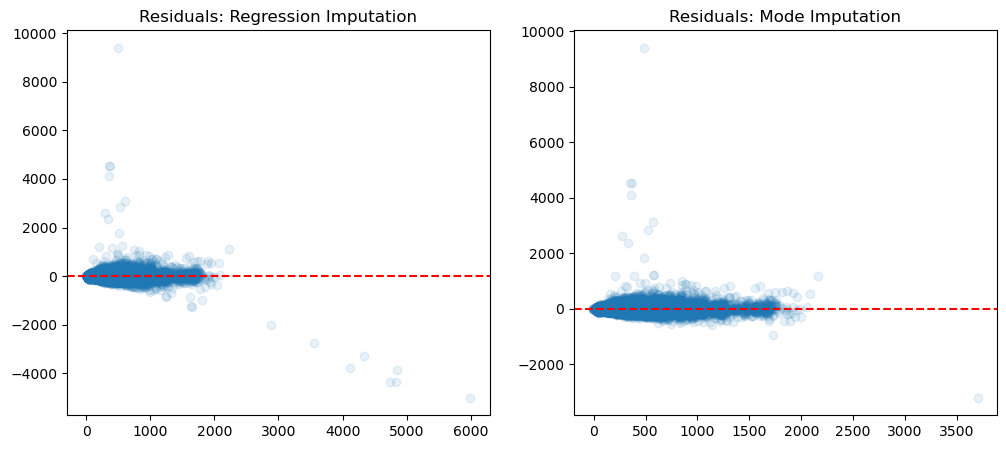

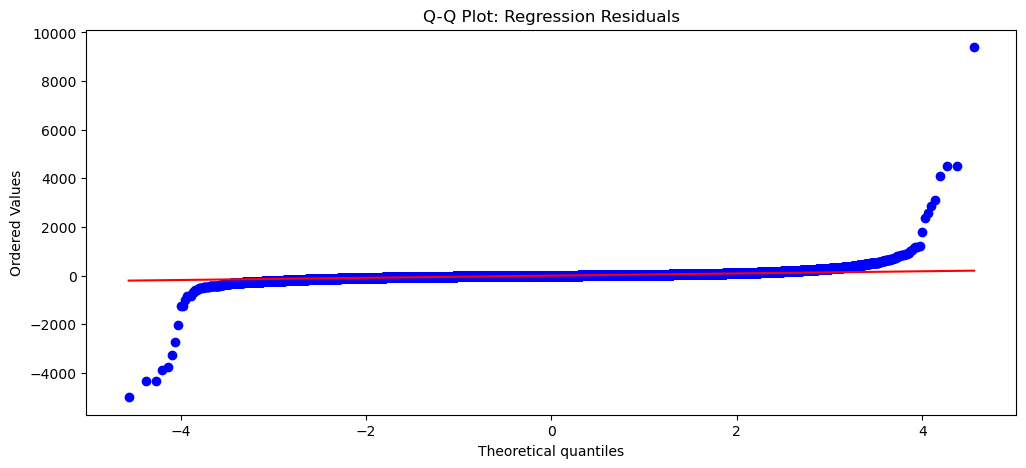

In [ ]:
#Visual Validation (Residual & Q-Q Plots)
#Patterns in residuals reveal inadequacies in the model or violations of assumptions.
# 3. Plotting Residuals 
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(preds_reg, res_reg, alpha=0.1)
plt.title("Residuals: Regression Imputation")
plt.axhline(0, color='red', linestyle='--')

plt.subplot(1, 2, 2)
plt.scatter(preds_mode, res_mode, alpha=0.1)
plt.title("Residuals: Mode Imputation")
plt.axhline(0, color='red', linestyle='--')
plt.show()

# 4. Q-Q Plot for Normality Check [cite: 64]
plt.figure(figsize=(12, 5))
stats.probplot(res_reg, dist="norm", plot=plt)
plt.title("Q-Q Plot: Regression Residuals")
plt.show()

In [45]:
# 3. Kolmogorov-Smirnov (K-S) Test
# Use this to compare the two imputed samples to see which one "departs" more from the expected distribution.
# Compare the distribution of a key imputed column (e.g., HSMainSystemEfficiency)
# to see which method distorted the original distribution more.
ks_stat, p_val = stats.ks_2samp(df_reg['HSMainSystemEfficiency'], df_mode['HSMainSystemEfficiency'])

print(f"\nKolmogorov-Smirnov Test: {ks_stat:.4f} (p-value: {p_val:.4f})")
if p_val < 0.05:
    print("The two imputation methods resulted in significantly different distributions.")


Kolmogorov-Smirnov Test: 0.0174 (p-value: 0.0000)
The two imputation methods resulted in significantly different distributions.


In [46]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

def clean_and_predict(file_path, label):
    # Load and drop the high-null column per lecture advice [cite: 838]
    df = pd.read_parquet(file_path).drop(columns=['PredominantRoofType'])
    
    # Identify numeric columns for the model
    X_cols = df.select_dtypes(include=[np.number]).columns.drop('BerRating').tolist()
    X = df[X_cols]
    y = df['BerRating']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Initial Baseline Prediction
    model = RandomForestRegressor(n_estimators=100, max_depth=12, n_jobs=-1, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    # --- LECTURE STEP: Outlier Detection via Residuals [cite: 15, 68] ---
    residuals = y_test - preds
    z_scores = np.abs(stats.zscore(residuals))
    
    # Keep only those within 3 standard deviations [cite: 29]
    filtered_mask = z_scores < 3
    y_test_clean = y_test[filtered_mask]
    preds_clean = preds[filtered_mask]
    
    print(f"\n--- {label} (Post-Outlier Removal) ---")
    print(f"Original Row Count: {len(y_test)}")
    print(f"Cleaned Row Count: {len(y_test_clean)}")
    print(f"MSE: {mean_squared_error(y_test_clean, preds_clean):.4f}")
    print(f"R-squared: {r2_score(y_test_clean, preds_clean):.4f}")
    
    return y_test_clean, preds_clean

# Run Comparison
reg_results = clean_and_predict('BER_Cleaned_Imputed_Regression.parquet', "Regression Imputation")
mode_results = clean_and_predict('BER_Cleaned_Final_fill_missing_values.parquet', "Mode Imputation")


--- Regression Imputation (Post-Outlier Removal) ---
Original Row Count: 270317
Cleaned Row Count: 268284
MSE: 1302.4248
R-squared: 0.9370

--- Mode Imputation (Post-Outlier Removal) ---
Original Row Count: 270317
Cleaned Row Count: 267514
MSE: 1286.4727
R-squared: 0.9362


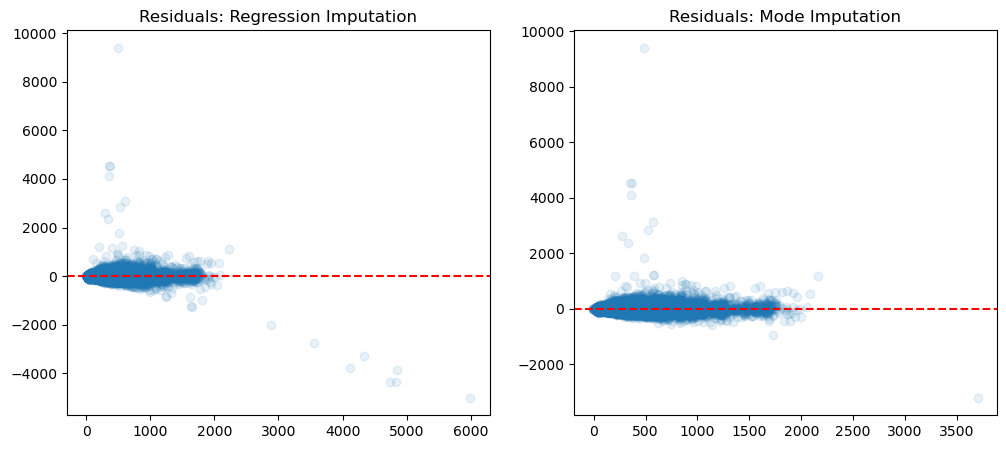

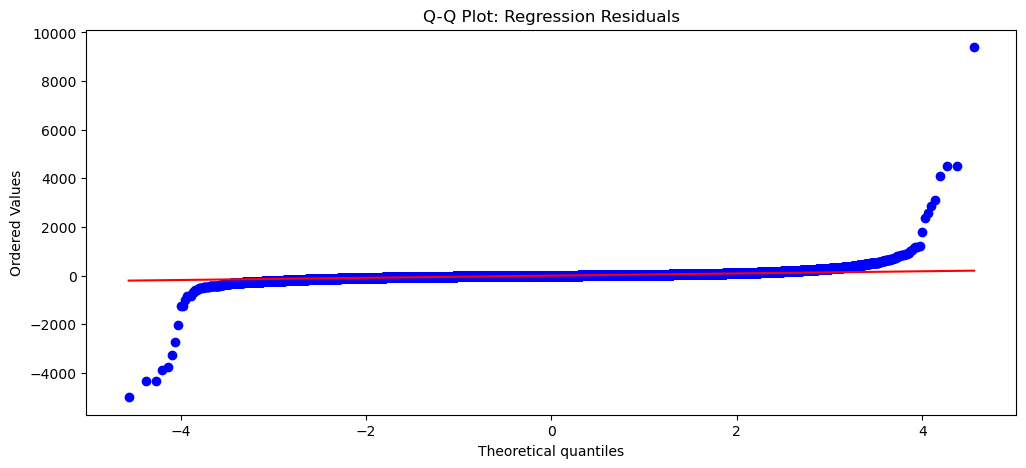

In [ ]:
#Visual Validation (Residual & Q-Q Plots)
#Patterns in residuals reveal inadequacies in the model or violations of assumptions.
# 3. Plotting Residuals 
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(preds_reg, res_reg, alpha=0.1)
plt.title("Residuals: Regression Imputation")
plt.axhline(0, color='red', linestyle='--')

plt.subplot(1, 2, 2)
plt.scatter(preds_mode, res_mode, alpha=0.1)
plt.title("Residuals: Mode Imputation")
plt.axhline(0, color='red', linestyle='--')
plt.show()

# 4. Q-Q Plot for Normality Check [cite: 64]
plt.figure(figsize=(12, 5))
stats.probplot(res_reg, dist="norm", plot=plt)
plt.title("Q-Q Plot: Regression Residuals")
plt.show()

In [48]:
# 3. Kolmogorov-Smirnov (K-S) Test
# Use this to compare the two imputed samples to see which one "departs" more from the expected distribution.
# Compare the distribution of a key imputed column (e.g., HSMainSystemEfficiency)
# to see which method distorted the original distribution more.
ks_stat, p_val = stats.ks_2samp(df_reg['HSMainSystemEfficiency'], df_mode['HSMainSystemEfficiency'])

print(f"\nKolmogorov-Smirnov Test: {ks_stat:.4f} (p-value: {p_val:.4f})")
if p_val < 0.05:
    print("The two imputation methods resulted in significantly different distributions.")


Kolmogorov-Smirnov Test: 0.0174 (p-value: 0.0000)
The two imputation methods resulted in significantly different distributions.
